# SKLEARN BASED PCA AND PLOTTING

In [14]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Data is in 892 rows (neurons) and 56 columns (8 sizes x 7 trials).
# Transform to 56 rows and 892 columns for PCA to reduce dimensionality down to 56 points with 3 dimensions.

Responses_R = np.loadtxt("st.csv", delimiter=",")
Responses = Responses_R.T
# print (Responses.shape)
# print(Responses[:10,:4])

### PCA with 3 Explicit Dimensions and visualize in 3D

scikit-learn PCA routine allows for explicit identification of number of dimensions in output dataset, where MATLAB does not.

Specifying number of dimensions avoids losing information by deleting additional dimensions without being factored into PCA solution.

Flip first and second principal components for "left to right" (otherwise goes from front to back).

Explained Variance Ratio: [0.25014177 0.16515748 0.09930196]
Shape of transformed data: (56, 3)


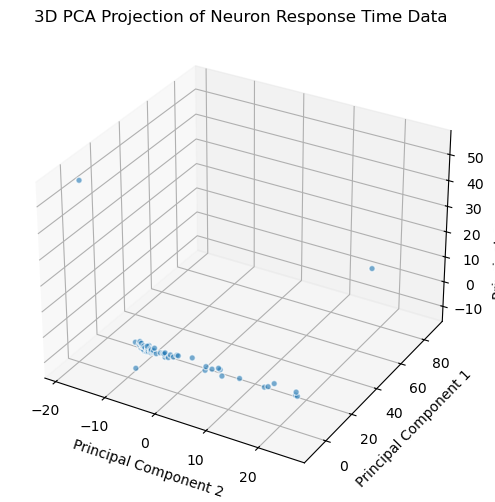

In [15]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(Responses)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Shape of transformed data:", principal_components.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(principal_components[:, 1],
           principal_components[:, 0],
           principal_components[:, 2],
           alpha = 0.6, edgecolors='w')
ax.set_xlabel("Principal Component 2")
ax.set_ylabel("Principal Component 1")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Projection of Neuron Response Time Data")
plt.show()

### PCA with 2 Explicit Dimensions and visualize in 2D

Very similar to 3D scatter plot - still shows strong linear relationship with outliers.  Doesn't lose much information with the reduction of an additional dimension.

Explained Variance Ratio: [0.25014177 0.16515748]
Shape of transformed data: (56, 2)


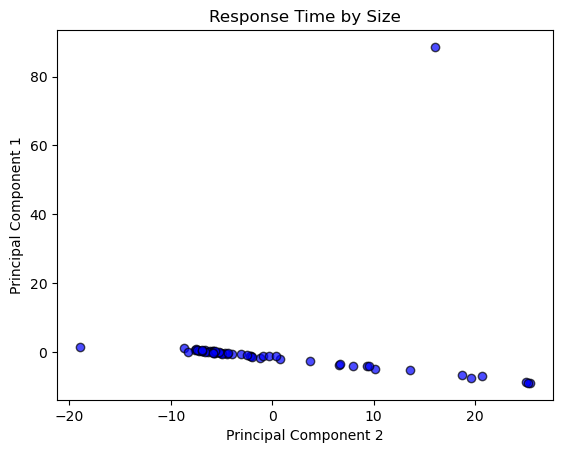

In [16]:
Responses_R = np.loadtxt("st.csv", delimiter=",")
Responses = Responses_R.T

pca = PCA(n_components=2)
principal_components = pca.fit_transform(Responses)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Shape of transformed data:", principal_components.shape)

x_values = principal_components[:, 1]
y_values = principal_components[:, 0]
plt.scatter(x_values, y_values, color='blue', alpha=0.7, edgecolors='black')
plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 1")
plt.title("Response Time by Size")
plt.show()

### PCA with 1 Explicit Dimension and visualize in 1D

Allows measurements of distances between points.

In 2D case, only outliers are distributed on y axis, so little information is lost.

Explained Variance Ratio: [0.25014177]
Shape of transformed data: (56, 1)


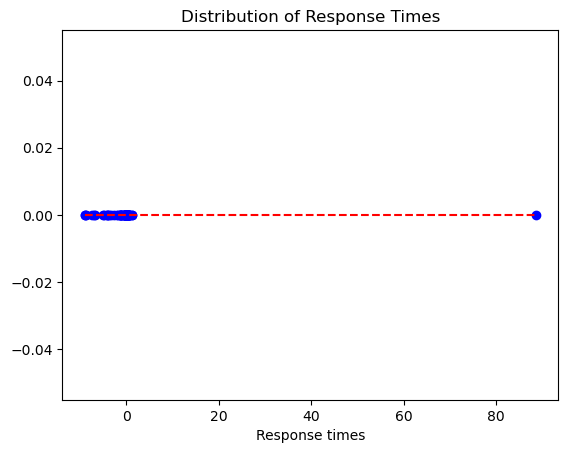

In [17]:
Responses_R = np.loadtxt("st.csv", delimiter=",")
Responses = Responses_R.T
pca = PCA(n_components=1)
principal_components = pca.fit_transform(Responses)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Shape of transformed data:", principal_components.shape)

x_values = principal_components
y_value = 0
plt.scatter(x_values, np.full_like(x_values, y_value), color='blue', label="Points on the line")
plt.plot([min(x_values), max(x_values)], [y_value, y_value], color='red', linestyle="--", label="Flat Line")
plt.xlabel("Response times")
plt.ylabel("")
plt.title("Distribution of Response Times")
plt.show()

### Spatial clustering over 2D PCA dataset

Perform spatial clustering to classify PCA attribute space

Plot with colors, borders, and heatmap to show point density.

Treated only the outliers as valid data, and all else as noise.

In [18]:
# Redo 2D PCA

Responses_R = np.loadtxt("st.csv", delimiter=",")
Responses = Responses_R.T
pca = PCA(n_components=2)
principal_components = pca.fit_transform(Responses)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Shape of transformed data:", principal_components.shape)
x_values = principal_components[:, 1]
y_values = principal_components[:, 0]

eps = 1 # Minimum distance between two points in the same cluster
min_samples = 2 # Minimum number of points to form a cluster
db = DBSCAN(eps=eps, min_samples=min_samples).fit(principal_components)
labels = db.labels_ # Cluster labels (-1 means noise/outlier)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Estimated number of clusters: {n_clusters}")

Explained Variance Ratio: [0.25014177 0.16515748]
Shape of transformed data: (56, 2)
Estimated number of clusters: 4


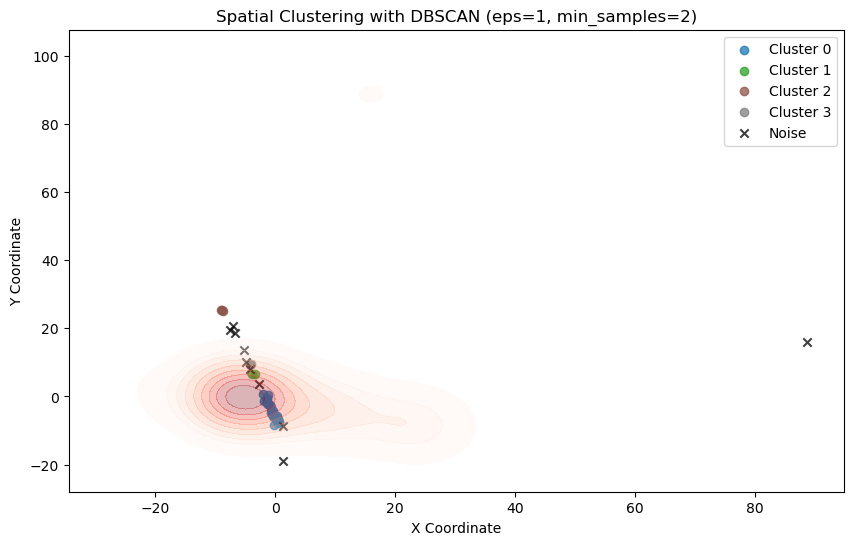

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        # Black for noise points
        color = "black"
        marker = "x"
    else:
        marker = "o"

    cluster_points = principal_components[labels == label]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[color], 
               label=f"Cluster {label}" if label != -1 else "Noise",
               facecolors="black", marker=marker, alpha=0.75)
sns.kdeplot(x=x_values, y=y_values, cmap="Reds", fill=True, alpha=0.3, ax=ax)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title(f"Spatial Clustering with DBSCAN (eps={eps}, min_samples={min_samples})")
ax.legend()

plt.show()

### 2D scatter plot (alternative to 2D PCA)

X axis as size and Y axis as response time.

Read in dataset with x,y pairs of size and response time.  This version uses all responses in all 7 trials, without distinguishing between trials.  Could be run individually over each trial and overlaid as well to keep each trial distinct.

The plot is not too interesting, since there's only 8 sizes, and all the measurements are clustered around each other, except for some outliers.

In [20]:
Responses = np.loadtxt("all_trials2.csv", delimiter=",")
# print (Responses.shape)
# print(Responses[:10,:])

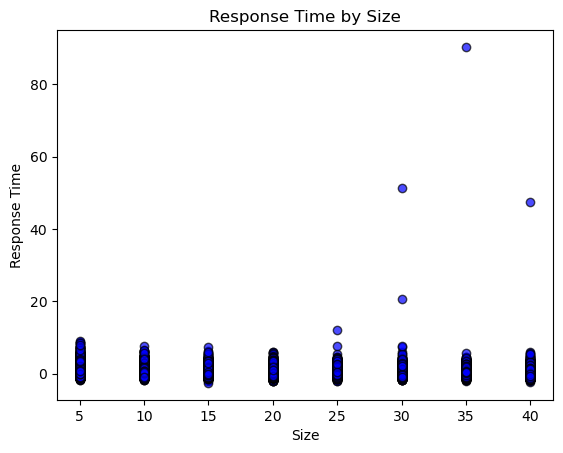

In [21]:
x_values = Responses[:, 0]
y_values = Responses[:, 1]
plt.scatter(x_values, y_values, color='blue', alpha=0.7, edgecolors='black')
plt.xlabel("Size")
plt.ylabel("Response Time")
plt.title("Response Time by Size")
plt.show()

# EVALUATING SIZE AS A CATEGORICAL VALUE

### ANOVA

In [22]:
import pandas as pd
from scipy.stats import f_oneway

# Load dataset
df = pd.read_csv("xy.csv")

# Define the dependent variable (measurement)
measurement_col = "Response"  # Replace with actual column name

# Apply ANOVA for each condition
for col in df.columns:
    if col != measurement_col:  # Exclude the dependent variable
        unique_values = df[col].nunique()

        # Ensure the condition is categorical-like (not too many unique values)
        if unique_values < 20:  
            groups = [df[df[col] == val][measurement_col].values for val in df[col].unique()]
            
            # Ensure there are at least two groups with data
            if all(len(g) > 1 for g in groups):
                stat, p = f_oneway(*groups)
                print(f"Condition: {col}, ANOVA p-value: {p}")
                
                if p < 0.05:
                    print(f"  → Significant difference, {col} is likely categorical.")
                else:
                    print(f"  → No significant difference, {col} might be numerical.")
            else:
                print(f"Condition: {col} skipped (some groups have insufficient data).")


Condition: Trial, ANOVA p-value: 2.3883831268732525e-08
  → Significant difference, Trial is likely categorical.
Condition: Size, ANOVA p-value: 2.5930589524541384e-303
  → Significant difference, Size is likely categorical.


### Decision Tree

In [23]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

# Load dataset
df = pd.read_csv("xy.csv")

# Define dependent (target) variable
measurement_col = "Response"  # Replace with actual column name

# Separate independent (conditions) and dependent variable
X = df.drop(columns=[measurement_col])  # Features (conditions)
y = df[measurement_col]  # Target (measurement)

# Handle categorical data by encoding it
X = pd.get_dummies(X, drop_first=True)  # One-hot encoding for categorical variables

# Train a Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X, y)

# Get feature importance
importances = model.feature_importances_

# Display feature importance
for col, imp in zip(X.columns, importances):
    print(f"{col}: Importance = {imp:.4f}")

# Optionally, sort and display most important features
sorted_features = sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True)
print("\nTop Important Features:")
for col, imp in sorted_features:
    print(f"{col}: {imp:.4f}")


Neuron: Importance = 0.6064
Trial: Importance = 0.1669
Size: Importance = 0.2267

Top Important Features:
Neuron: 0.6064
Size: 0.2267
Trial: 0.1669


### Box Plots

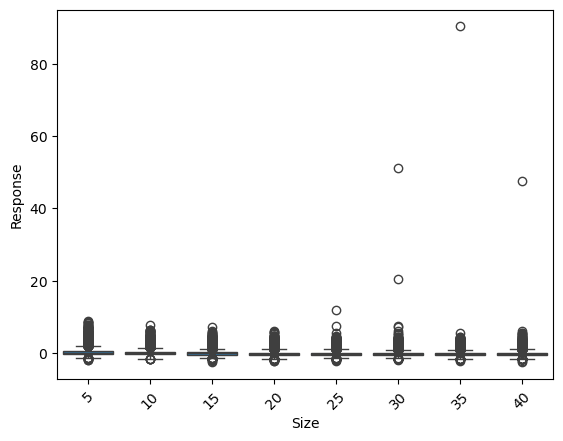

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Size", y="Response", data=df)
plt.xticks(rotation=45)  # Rotate labels if needed
plt.show()


### Scatterplots

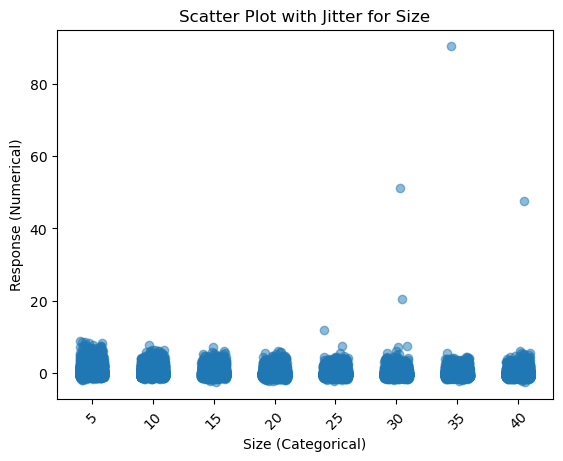

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load dataset
df = pd.read_csv("xy.csv")

# Add jitter to categorical condition values
x_jittered = df["Size"].astype("category").cat.codes + np.random.uniform(-0.2, 0.2, size=len(df))

plt.scatter(x_jittered, df["Response"], alpha=0.5)
plt.xticks(ticks=range(len(df["Size"].unique())), labels=df["Size"].unique(), rotation=45)
plt.xlabel("Size (Categorical)")
plt.ylabel("Response (Numerical)")
plt.title("Scatter Plot with Jitter for Size")
plt.show()


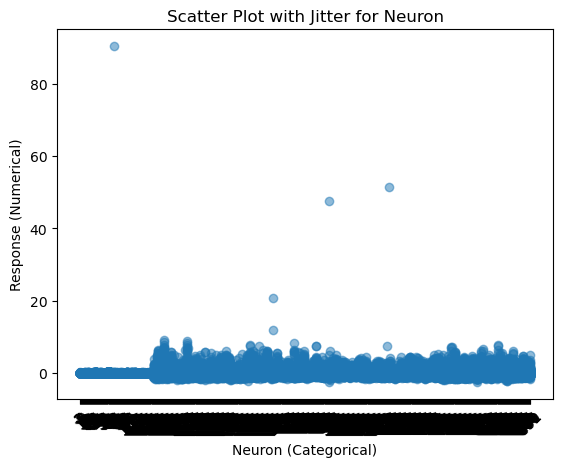

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Add jitter to categorical condition values
x_jittered = df["Neuron"].astype("category").cat.codes + np.random.uniform(-0.2, 0.2, size=len(df))

plt.scatter(x_jittered, df["Response"], alpha=0.5)
plt.xticks(ticks=range(len(df["Neuron"].unique())), labels=df["Neuron"].unique(), rotation=45)
plt.xlabel("Neuron (Categorical)")
plt.ylabel("Response (Numerical)")
plt.title("Scatter Plot with Jitter for Neuron")
plt.show()

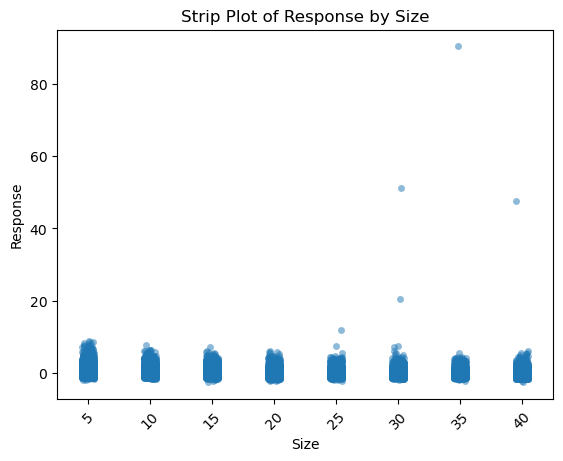

In [27]:
sns.stripplot(x="Size", y="Response", data=df, jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.title("Strip Plot of Response by Size")
plt.show()

# CLASSIFYING BY ONLY RESPONSE (IGNORING SIZE AND TRIAL)

### K-Means Clustering

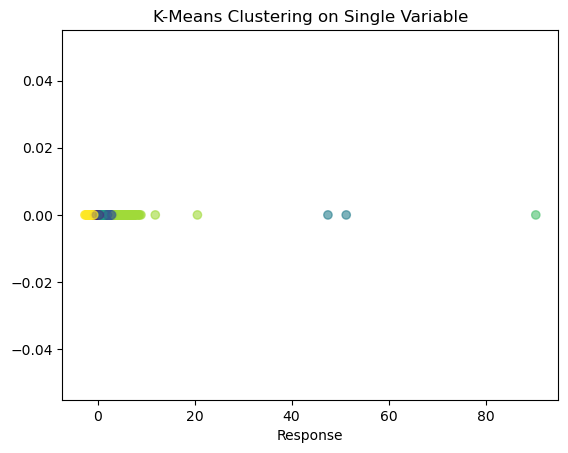

In [28]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("xy.csv")

X = df["Response"].values.reshape(-1, 1)  # Reshape for clustering

# Apply K-Means with 3 clusters (adjust as needed)
kmeans = KMeans(n_clusters=8, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Plot results
plt.scatter(df["Response"], np.zeros_like(df["Response"]), c=df["cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Response")
plt.title("K-Means Clustering on Single Variable")
plt.show()


### Gaussian Mixture Model

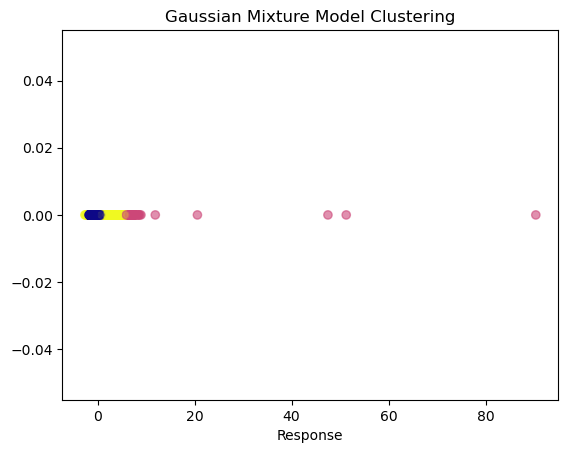

In [29]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
df["cluster"] = gmm.fit_predict(X)

plt.scatter(df["Response"], np.zeros_like(df["Response"]), c=df["cluster"], cmap="plasma", alpha=0.6)
plt.xlabel("Response")
plt.title("Gaussian Mixture Model Clustering")
plt.show()


### DBSCAN

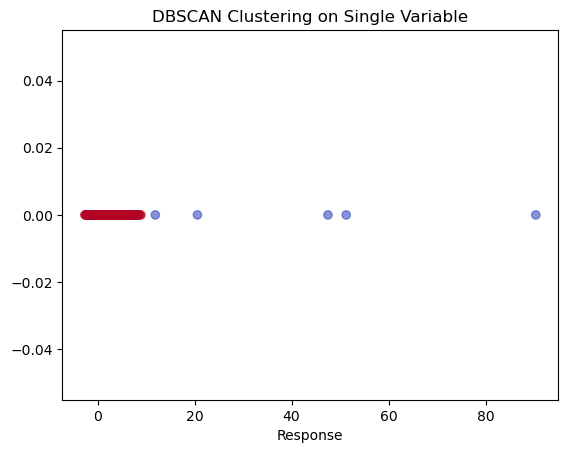

In [31]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1, min_samples=5)  # Adjust eps for better clustering
df["cluster"] = dbscan.fit_predict(X)

plt.scatter(df["Response"], np.zeros_like(df["Response"]), c=df["cluster"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Response")
plt.title("DBSCAN Clustering on Single Variable")
plt.show()


### Quantile Based Binning

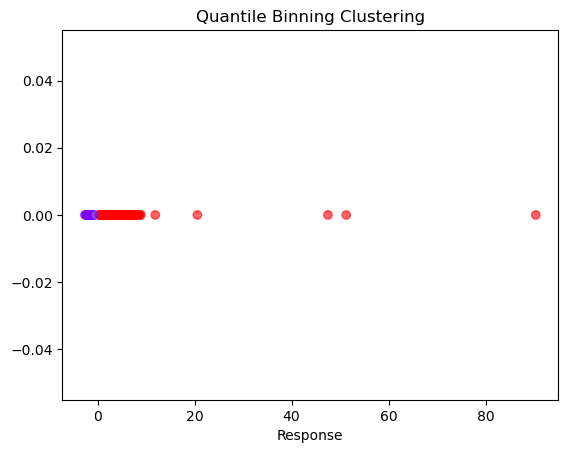

In [32]:
df["cluster"] = pd.qcut(df["Response"], q=3, labels=False)

plt.scatter(df["Response"], np.zeros_like(df["Response"]), c=df["cluster"], cmap="rainbow", alpha=0.6)
plt.xlabel("Response")
plt.title("Quantile Binning Clustering")
plt.show()


# K-Means on the 56D dataset, 
# PCA to plot in 2D and/or 3D

Choosing the Number of Clusters (K)

Since K-Means requires you to specify  K , use methods to find the best value:
- Elbow Method: Plot inertia (sum of squared distances) vs.  K  and look for the “elbow.”
- Silhouette Score: Measures how well points fit in clusters.
- Gap Statistic: Compares clustering performance to a random dataset.

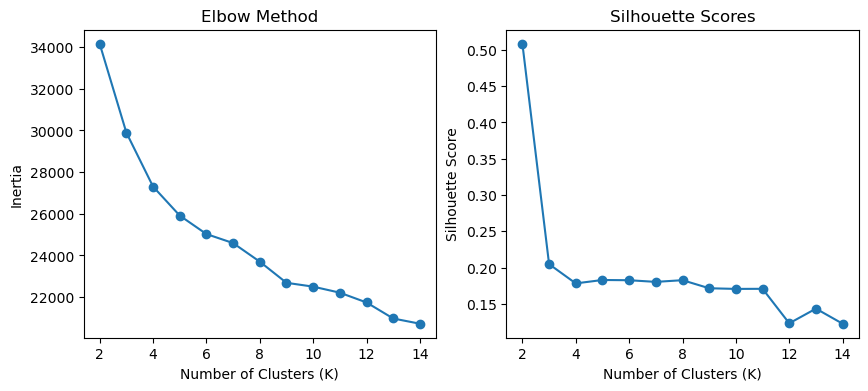

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load your dataset
df = pd.read_csv("size_trials2.csv")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()


Run K-Means on the dataset and plot 2D (use PCA to project)

K-Means is an unsupervised learning algorithm used for clustering data into  K  groups. It tries to partition the dataset so that points in the same cluster are more similar to each other than to points in other clusters.

Running K-Means on the original dataset preserves all information in the clustering, then only reduces dimensions to visualize (rather than reducing dimensions and running dimensions).

Cluster
0    402
3    336
2    109
1     44
Name: count, dtype: int64


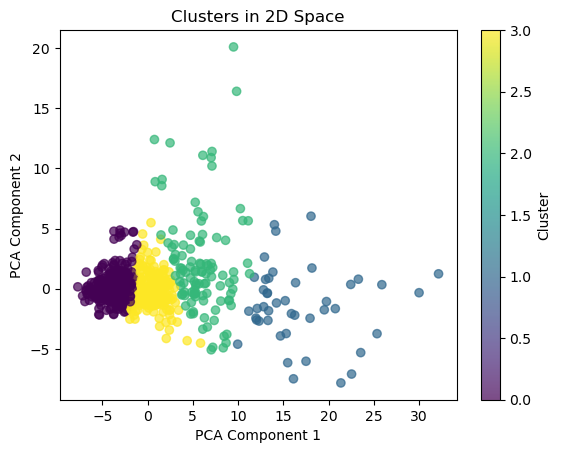

In [38]:
# Choose the best K based on Elbow or Silhouette
optimal_k = 4  # Replace with your chosen K

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster distribution
print(df['Cluster'].value_counts())

# Add cluster labels back to the original dataset
df.to_csv("clustered_data.csv", index=False)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters in 2D Space")
plt.colorbar(label="Cluster")
plt.show()

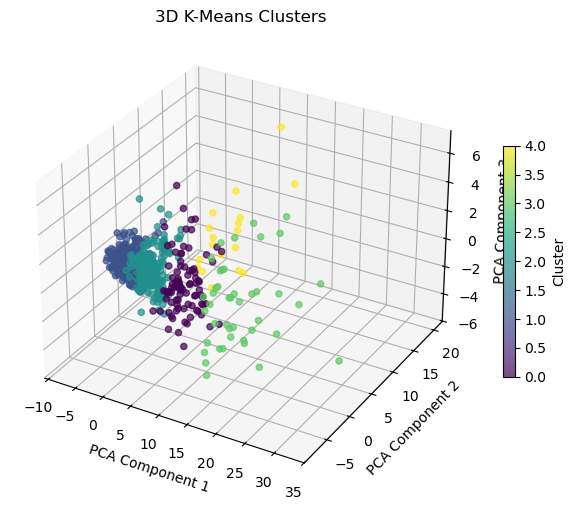

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("size_trials2.csv")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Choose optimal K (modify based on Elbow or Silhouette)
optimal_k = 5  # Replace with the chosen K

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Reduce dimensions to 3D using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 3D Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=df['Cluster'], cmap='viridis', alpha=0.7)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()
